In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2

In [ ]:
# Import Labels' Dictionary, Train, Test

import pickle

with open("../saved_models/ann_train.pkl", "rb") as f:
  ann_train = pickle.load(f)

with open("../saved_models/orderLabels.pkl", "rb") as f:
  orderLabels = pickle.load(f)

with open("../saved_models/labelEncoder.pkl", "rb") as f:
  labelEncoder = pickle.load(f)

In [ ]:
# Get x_train, y_train

x = ann_train.drop(columns = ["diagnostic"]).astype(np.float32)
print(x.keys())
print(len(x.keys()))

y = ann_train["diagnostic"]

Index(['age', 'gender', 'smoke', 'drink', 'skin_cancer_history',
       'cancer_history', 'pesticide', 'biopsed', 'grew', 'hurt', 'bleed',
       'itch', 'elevation', 'changed', 'diameter_1', 'diameter_2',
       'has_sewage_system', 'has_piped_water', 'race', 'region_ARM',
       'region_BACK', 'region_CHEST', 'region_EAR', 'region_FACE',
       'region_FOOT', 'region_FOREARM', 'region_HAND', 'region_LIP',
       'region_NECK', 'region_NOSE', 'region_SCALP', 'region_THIGH'],
      dtype='object')
32


In [ ]:
# Split The Data

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42, stratify = y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42, stratify = y_train)

In [ ]:
print(x_train.shape)
print(y_train.shape)

(3088, 32)
(3088,)


In [ ]:
# Labels OneHotEncoding

from sklearn.preprocessing import LabelEncoder

y_train = labelEncoder.transform(y_train)
y_test = labelEncoder.transform(y_test)
y_val = labelEncoder.transform(y_val)
print(labelEncoder.classes_)

orderLabels = labelEncoder.classes_

print(labelEncoder.classes_[0])

['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
ACK


In [21]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.metrics import AUC

print(y_train)
y_train = tf.keras.utils.to_categorical(y_train).astype(np.float32)
y_test = tf.keras.utils.to_categorical(y_test).astype(np.float32)
y_val = tf.keras.utils.to_categorical(y_val).astype(np.float32)
print(y_train)

ann = Sequential()

[1 2 4 ... 1 4 0]
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]]


In [22]:
ann.add(Dense(units = 128, input_shape = (x_train.shape[1], ), activation = "relu"))
ann.add(Dropout(0.3))
ann.add(Dense(units = 64, activation = "relu"))
ann.add(Dense(units = 32, activation = "relu"))
ann.add(Dense(units = 6, activation = "softmax"))

c:\ProgramData\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy", "Recall", AUC(name = "auc", multi_label = True)])

checkPoint = ModelCheckpoint("../saved_models/best_ann_model.keras", monitor = "val_accuracy", mode = "max")
earlyStopping = EarlyStopping(monitor = "val_accuracy", mode = "max", patience = 10, restore_best_weights = True)

hist = ann.fit(x_train, y_train, epochs = 100, validation_data = (x_val, y_val), batch_size = 32, callbacks = [checkPoint, earlyStopping])

Epoch 1/100


97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - Recall: 0.3248 - accuracy: 0.5599 - auc: 0.7456 - loss: 1.2291 - val_Recall: 0.6010 - val_accuracy: 0.6995 - val_auc: 0.9189 - val_loss: 0.8420
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Recall: 0.6124 - accuracy: 0.6933 - auc: 0.9059 - loss: 0.8273 - val_Recall: 0.6891 - val_accuracy: 0.7487 - val_auc: 0.9448 - val_loss: 0.6819
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Recall: 0.6742 - accuracy: 0.7487 - auc: 0.9262 - loss: 0.7115 - val_Recall: 0.7098 - val_accuracy: 0.7694 - val_auc: 0.9506 - val_loss: 0.6273
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Recall: 0.7060 - accuracy: 0.7659 - auc: 0.9402 - loss: 0.6356 - val_Recall: 0.7383 - val_accuracy: 0.7785 - val_auc: 0.9560 - val_loss: 0.5810
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Recall: 0.7111 - accuracy: 0.7688 - auc: 0.9442 - loss: 0.6154 - val_Recall: 0.7345 - val_accuracy: 0.7979 - val_auc: 0.9581 - val_loss: 0.5587
Epoch 6/100
97/97 ━━━━━━━━

In [24]:
ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,276 (172.96 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,518 (115.31 KB)

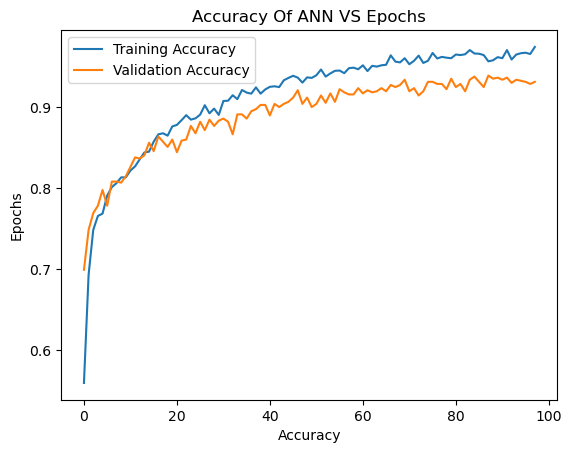

In [25]:
# Accuracy Visualization

plt.plot(hist.history["accuracy"], label = "Training Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Accuracy Of ANN VS Epochs")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")

plt.legend()
plt.show()

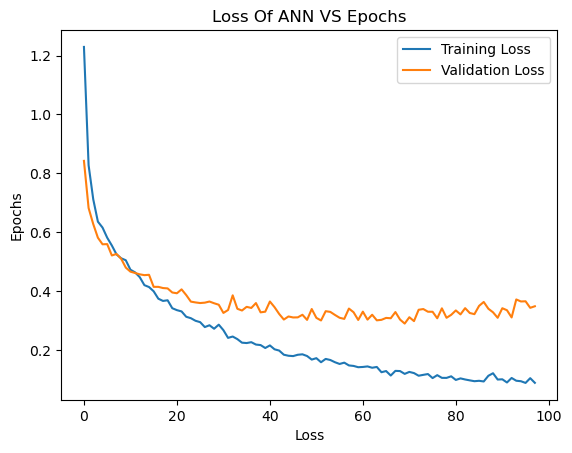

In [26]:
# Loss Visualization

plt.plot(hist.history["loss"], label = "Training Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")

plt.title("Loss Of ANN VS Epochs")
plt.xlabel("Loss")
plt.ylabel("Epochs")

plt.legend()
plt.show()

In [27]:
# Evaluate The model

evaluateModel = ann.evaluate(x_test, y_test)

print(f"Model Loss: {evaluateModel[0]}")
print(f"Model Accuracy: {evaluateModel[1]}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Recall: 0.9323 - accuracy: 0.9335 - auc: 0.9735 - loss: 0.4254
Model Loss: 0.42536163330078125
Model Accuracy: 0.9335347414016724


In [28]:
# Predict ANN Input

input = x_train.iloc[0].values
input = np.expand_dims(input, axis = 0)

print(ann.predict(input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[9.7678416e-08 9.9954349e-01 2.2476365e-10 3.4165992e-09 4.5638546e-04
  1.3049126e-10]]


In [ ]:
# Save Model

ann.save("../saved_models/ann_model.keras")

In [ ]:
# Export Train, Test

# import pickle

# with open("x_train_ann.pkl", "wb") as f:
#   pickle.dump(x_train, f)

# with open("y_train_ann.pkl", "wb") as f:
#   pickle.dump(y_train, f)

# with open("x_test_ann.pkl", "wb") as f:
#   pickle.dump(x_test, f)

# with open("y_test_ann.pkl", "wb") as f:
#   pickle.dump(y_test, f)